In [6]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10, UR10_sandbox, Trajectories
import optimal.metrics as metrics
import numpy as np
import time

type = UR10_sandbox
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

DT = robot_mj_model.model.opt.timestep
path = Trajectories.joint_6dof
nq = len(robot_pin_model.q_indices)
nv = len(robot_pin_model.v_indices)

MAX_ERROR_DEG = 0.5  # hard ceiling on the position error

def evaluate(kp, kd, DT, path, time_limit=1000, max_error_deg=MAX_ERROR_DEG, get_xs_us=False, alpha=1.0):
    controller = RobotController(robot_pin_model)
    xs, us = [], []
    try:
        current_q = path[0]
        current_v = np.zeros(nv)
        for i in range(1, len(path)):
            x_start = np.concatenate([current_q, current_v])
            x_goal = np.concatenate([path[i], np.zeros(nv)])
            t_xs, t_us = controller.compute_control(
                x_start=x_start, x_goal=x_goal,
                T=time_limit, DT=DT, kp=kp, kd=kd, alpha=alpha, option="pd")
            current_q = t_xs[-1][:nq]
            current_v = t_xs[-1][nq:]
            xs.extend(t_xs)
            us.extend(t_us)
    except Exception as e:
        print(f"Solver failed with error: {e}")
        if get_xs_us:
            return float("inf"), [], []
        return float("inf")
    prec_deg = metrics.tracking_error(xs, path[1:], [time_limit] * (len(path) - 1))
    energy = metrics.thermal_energy(us, DT) + metrics.mechanical_work(us, xs, DT)
    score = energy
    if prec_deg > max_error_deg:
        score += 1e9 * (prec_deg - max_error_deg)  # hard precision barrier
    if get_xs_us:
        return float("inf") if np.isnan(score) else float(score), xs, us
    return float("inf") if np.isnan(score) else float(score)

def coordinate_grid_search(kp_grids, ratio_grids, kp_init, ratio_init,
                           DT, path, n_passes=3, verbose=True, alpha=1.0):
    # Per-joint coarse grid searched one joint at a time (coordinate descent).
    # A full Cartesian product of 6 kp x 6 ratio axes is intractable
    # (e.g. 5**12 ~ 2.4e8 evaluations), so each joint's (kp, ratio) sub-grid is
    # swept while the other joints are held at their current best value.
    kp = np.array(kp_init, dtype=float)
    ratio = np.array(ratio_init, dtype=float)
    best = evaluate(kp, kp * ratio, DT, path, alpha=alpha)
    n_eval = 1
    for p in range(n_passes):
        improved = False
        for j in range(len(kp)):
            for kp_val in kp_grids[j]:
                for r_val in ratio_grids[j]:
                    t_kp = kp.copy()
                    t_kp[j] = kp_val
                    t_ratio = ratio.copy()
                    t_ratio[j] = r_val
                    s = evaluate(t_kp, t_kp * t_ratio, DT, path)
                    n_eval += 1
                    if s < best:
                        best, kp, ratio, improved = s, t_kp, t_ratio, True
        if verbose:
            print(f"Pass {p + 1}: best = {best:.4e}  (evals: {n_eval})")
        if not improved:
            break
    return kp, ratio, best, n_eval

Pass 1: best = 2.6134e+10  (evals: 91)
Pass 2: best = 4.6093e+09  (evals: 181)
Pass 3: best = 1.2716e+05  (evals: 271)
Pass 4: best = 1.2716e+05  (evals: 361)
Grid best score: 127158.0220226911  evaluations: 361
Grid kp: [400. 400. 400.   5.   1.   1.]
Grid kd: [6.0e+01 6.0e+01 2.0e+01 7.5e-01 1.5e-01 5.0e-02]
Joint     Corr FF↔tot  RMS FF %  RMS FB %    MAE FB
-------------------------------------------------------
  1            0.9953     99.1%      9.7%    1.8136
  2            0.9853     98.6%     12.7%    2.8921
  3            0.8408     97.6%     44.6%    4.4292
  4            0.7979     91.6%     52.9%    0.3796
  5            0.7149     92.5%     73.0%    0.1541
  6            0.9871     96.9%     16.1%    0.0065
Global FF coverage: 98.6%   FB correction: 20.3%
Global correlation FF↔tot: 0.9771


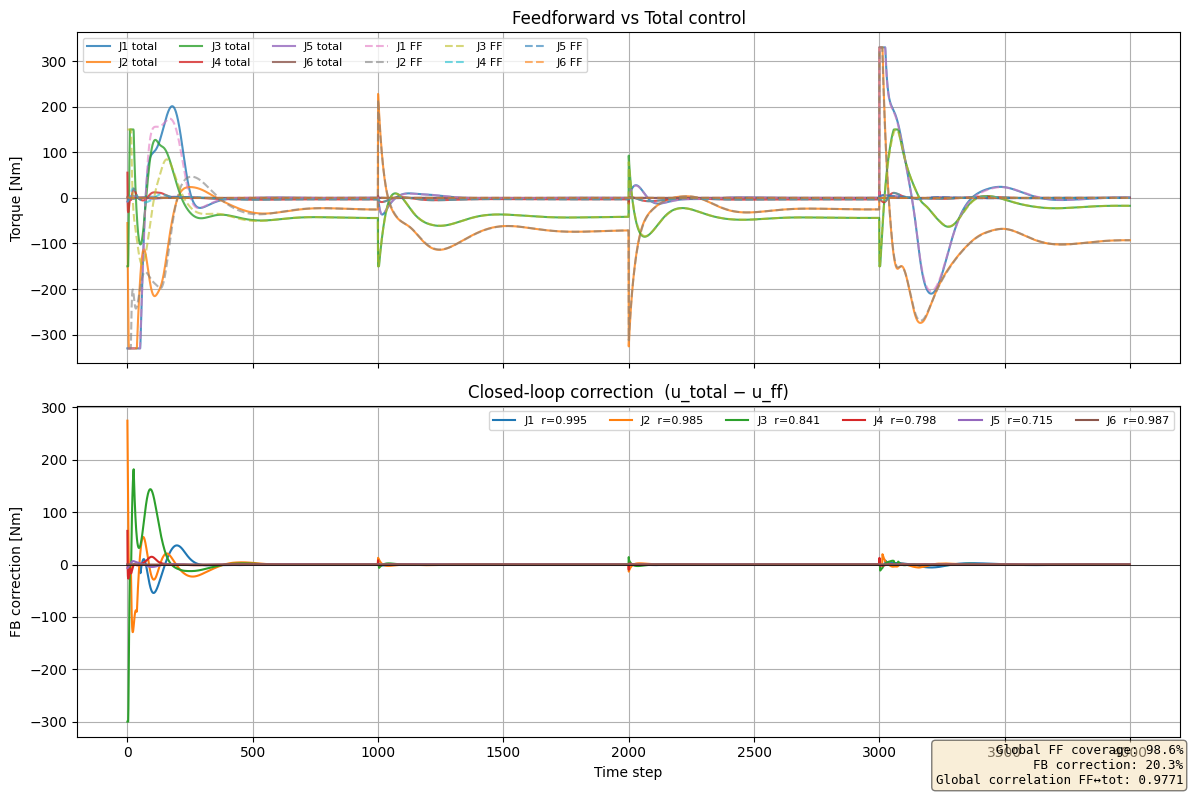

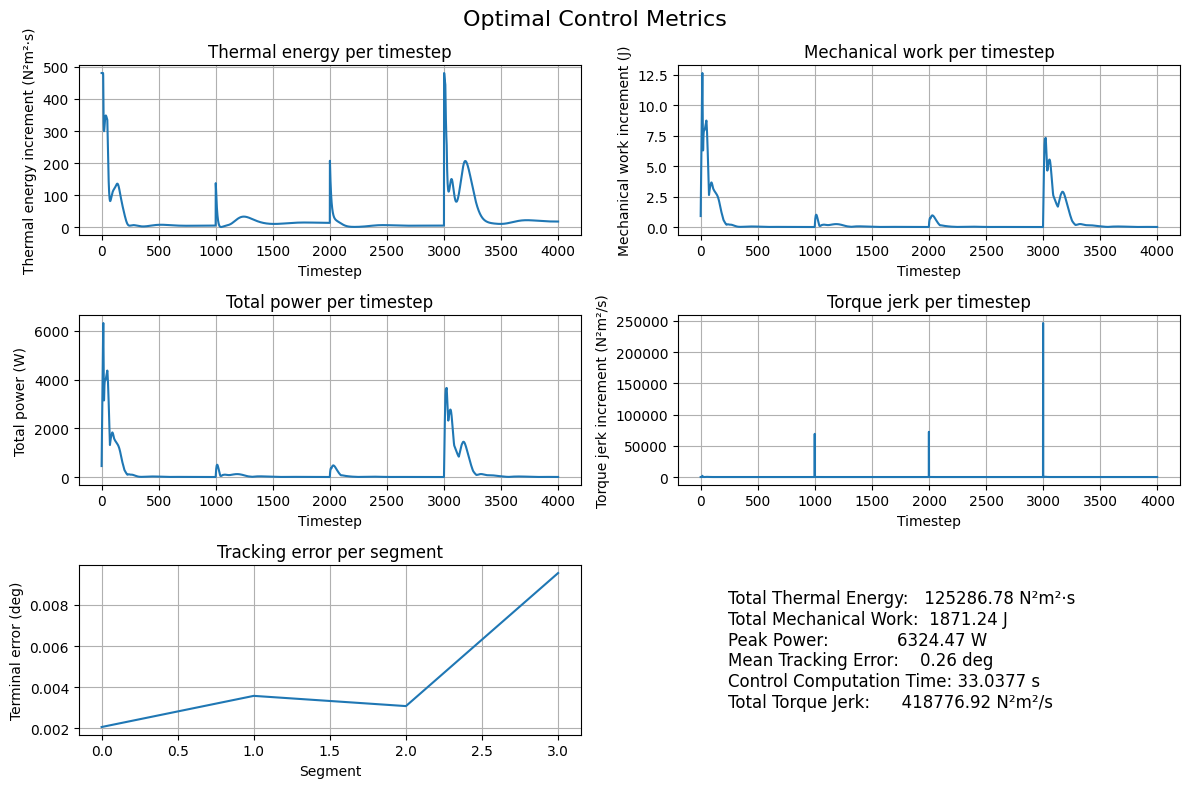

In [4]:
kp_grids = [
    np.array([5, 20, 60, 150, 400]),
    np.array([5, 20, 60, 150, 400]),
    np.array([5, 20, 60, 150, 400]),
    np.array([1, 5, 15, 40, 100]),
    np.array([1, 5, 15, 40, 100]),
    np.array([1, 5, 15, 40, 100]),
]
ratio_grids = [np.array([0.05, 0.10, 0.15])] * 6
kp_init = np.array([60.0, 60.0, 60.0, 15.0, 15.0, 15.0])
ratio_init = np.array([0.10] * 6)

start_time = time.time()
kp_grid, ratio_grid, score_grid, n_eval = coordinate_grid_search(
    kp_grids, ratio_grids, kp_init, ratio_init, DT, path, n_passes=4)
_, xs, us = evaluate(kp_grid, kp_grid * ratio_grid, DT, path, time_limit=1000, max_error_deg=MAX_ERROR_DEG, get_xs_us=True)
end_time = time.time()
controller_time = end_time - start_time
kd_grid = kp_grid * ratio_grid
print("Grid best score:", score_grid, " evaluations:", n_eval)
print("Grid kp:", np.round(kp_grid, 3))
print("Grid kd:", np.round(kd_grid, 3))
xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=type.kp, kd=type.kd)
robot_mj_model.plot_feedback_part(us_real, us)
metrics.plot_metrics(us, xs, DT, path[1:], [1000]*(len(path)-1), controller_time)

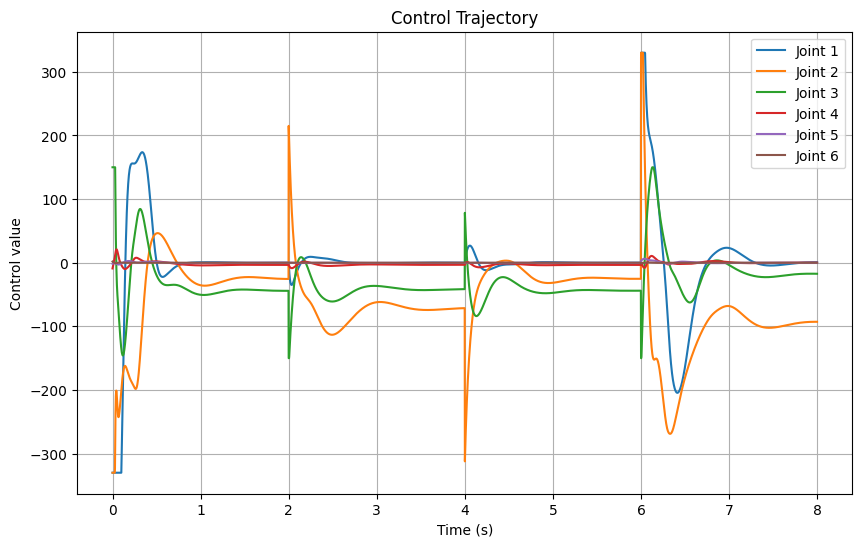

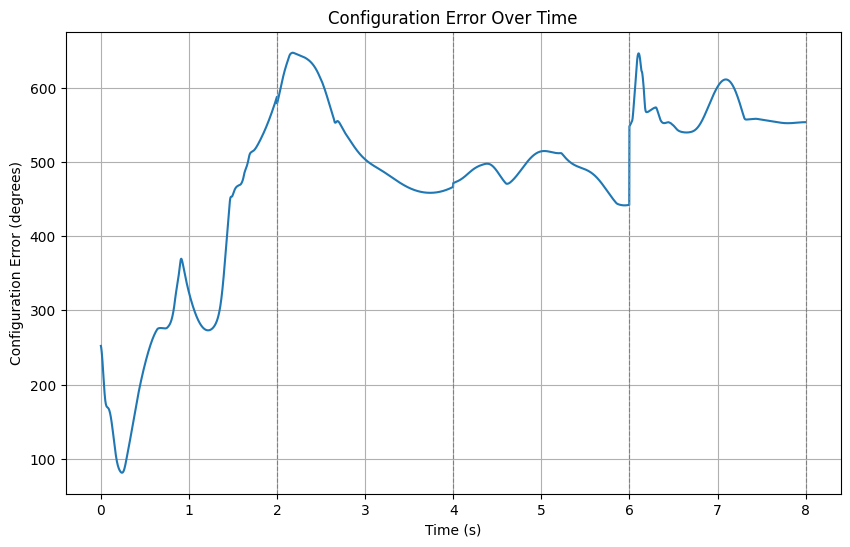

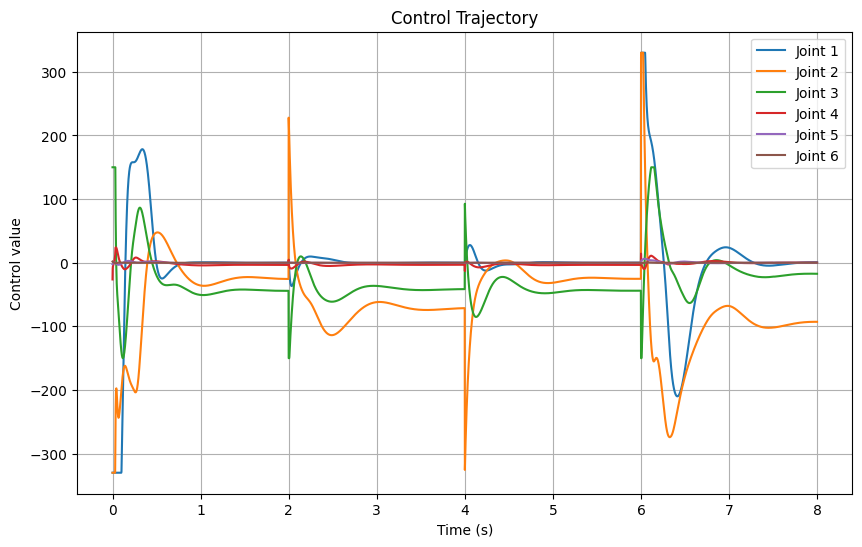

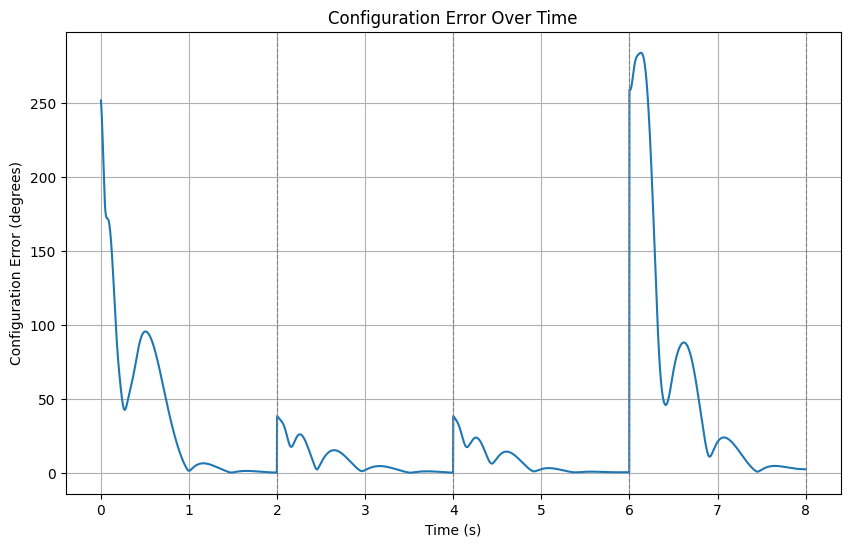

In [3]:
# Visualize Path computed by Mujoco - Open loop control with ideal model
robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
robot_mj_model.reset()
# Visualize Path executed by Mujoco - Open loop control without feedback
xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)
robot_mj_model.reset()
# Visualize Path executed by Mujoco - Closed loop control with feedback
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)



Pass 1: best = 2.0937e+10  (evals: 91)
Pass 2: best = 5.9125e+04  (evals: 181)
Pass 3: best = 5.9120e+04  (evals: 271)
Pass 4: best = 5.9120e+04  (evals: 361)
Grid best score: 59119.5621189679  evaluations: 361
Grid kp: [400. 400. 400. 100.   5.   1.]
Grid kd: [2.e+01 6.e+01 4.e+01 5.e+00 5.e-01 5.e-02]
Joint     Corr FF↔tot  RMS FF %  RMS FB %    MAE FB
-------------------------------------------------------
  1            0.9999     99.0%      1.9%    0.3597
  2            0.9998     99.8%      1.2%    0.3108
  3            0.9981     99.7%      2.5%    0.2482
  4            0.9625     94.3%     22.2%    0.0799
  5            0.9988     99.0%      5.0%    0.0180
  6            1.0000     96.5%      3.5%    0.0049
Global FF coverage: 99.7%   FB correction: 1.8%
Global correlation FF↔tot: 0.9998


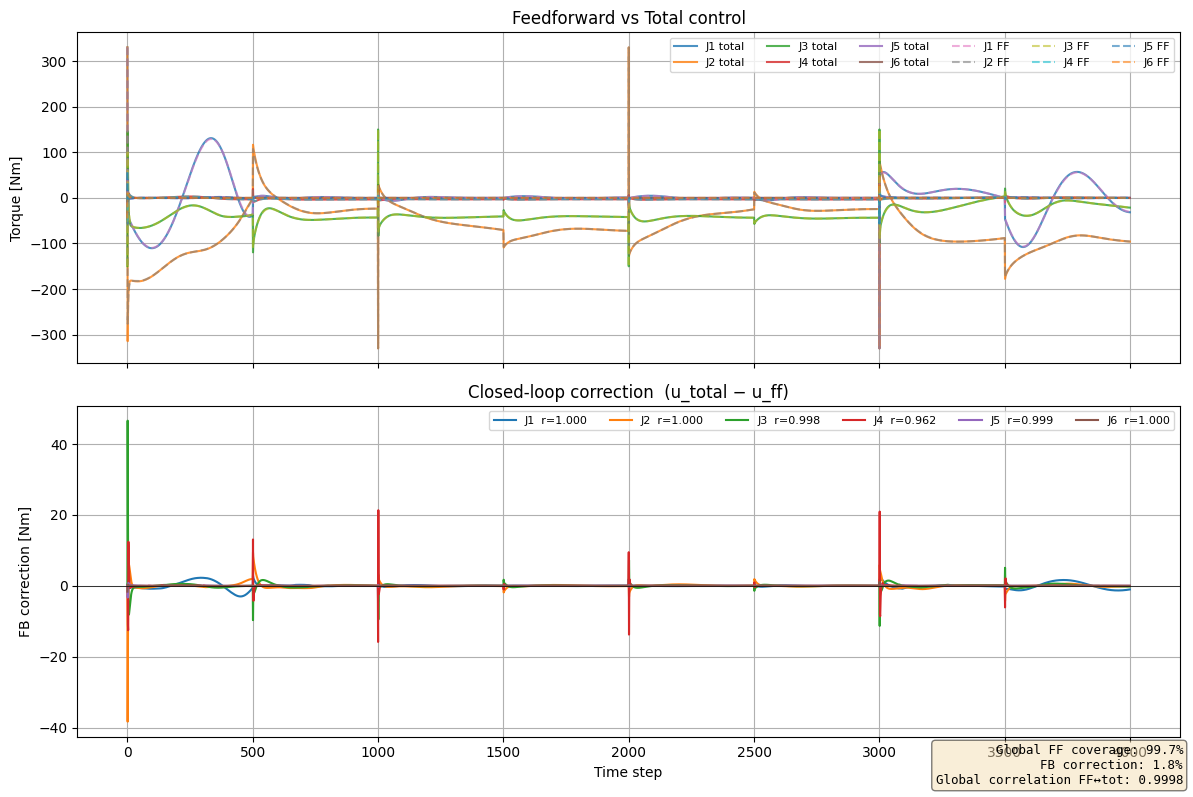

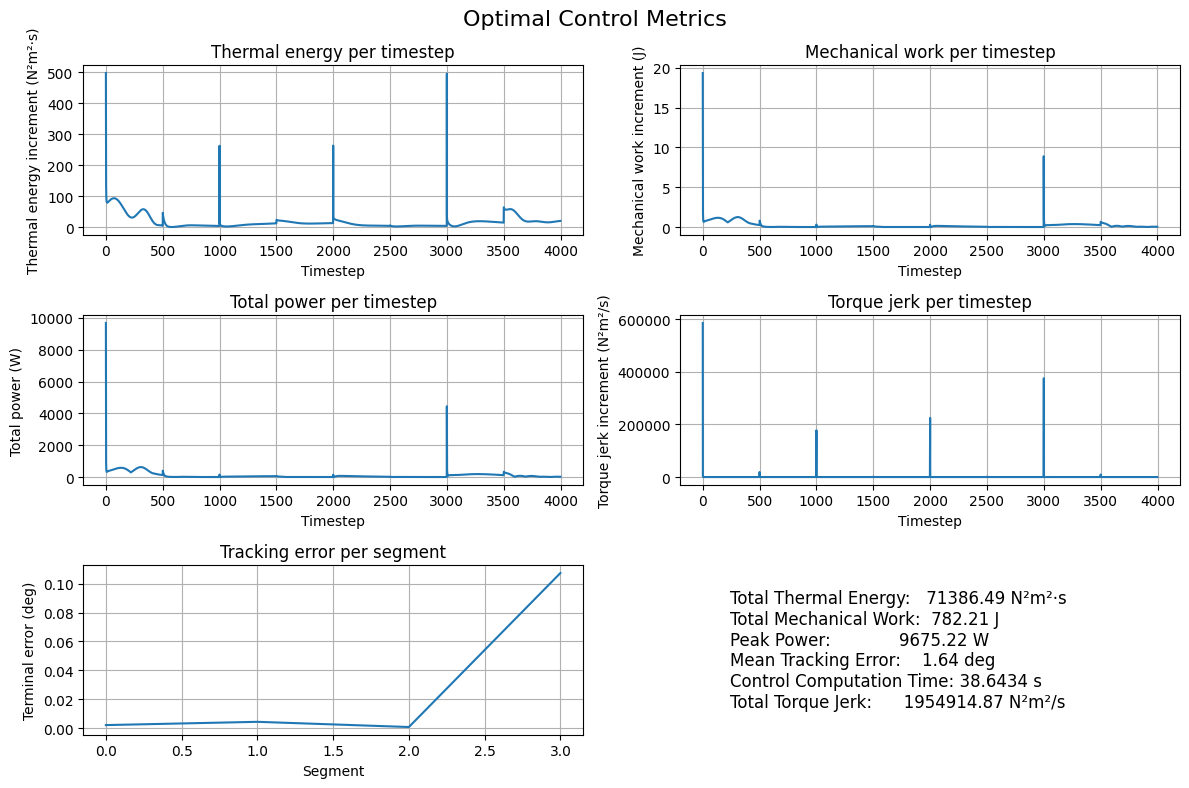

In [7]:
kp_grids = [
    np.array([5, 20, 60, 150, 400]),
    np.array([5, 20, 60, 150, 400]),
    np.array([5, 20, 60, 150, 400]),
    np.array([1, 5, 15, 40, 100]),
    np.array([1, 5, 15, 40, 100]),
    np.array([1, 5, 15, 40, 100]),
]
ratio_grids = [np.array([0.05, 0.10, 0.15])] * 6
kp_init = np.array([60.0, 60.0, 60.0, 15.0, 15.0, 15.0])
ratio_init = np.array([0.10] * 6)

start_time = time.time()
kp_grid, ratio_grid, score_grid, n_eval = coordinate_grid_search(
    kp_grids, ratio_grids, kp_init, ratio_init, DT, path, n_passes=4, alpha=0.5)
_, xs, us = evaluate(kp_grid, kp_grid * ratio_grid, DT, path, time_limit=1000, max_error_deg=MAX_ERROR_DEG, get_xs_us=True, alpha=0.5)
end_time = time.time()
controller_time = end_time - start_time
kd_grid = kp_grid * ratio_grid
print("Grid best score:", score_grid, " evaluations:", n_eval)
print("Grid kp:", np.round(kp_grid, 3))
print("Grid kd:", np.round(kd_grid, 3))
xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=type.kp, kd=type.kd)
robot_mj_model.plot_feedback_part(us_real, us)
metrics.plot_metrics(us, xs, DT, path[1:], [1000]*(len(path)-1), controller_time)

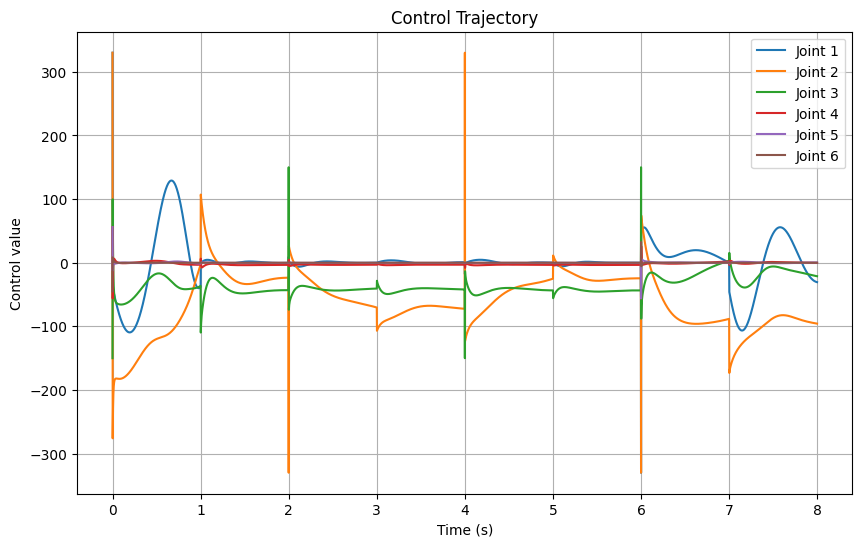

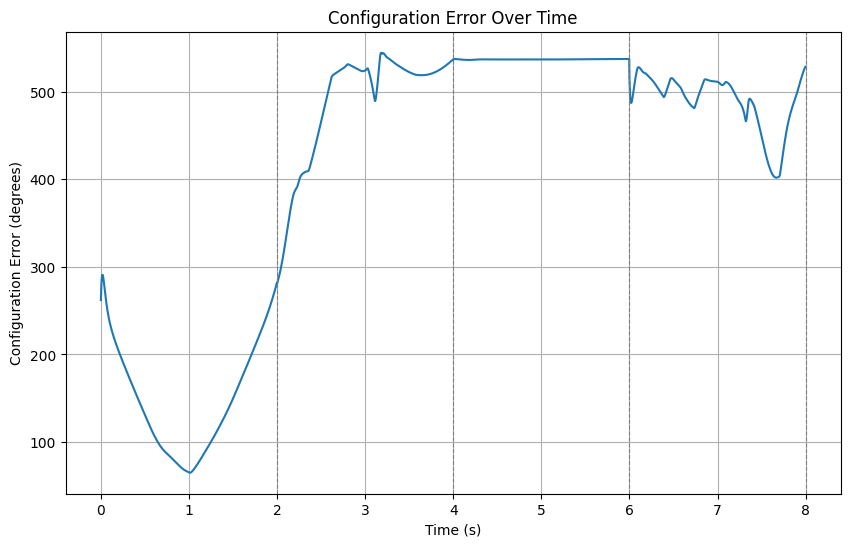

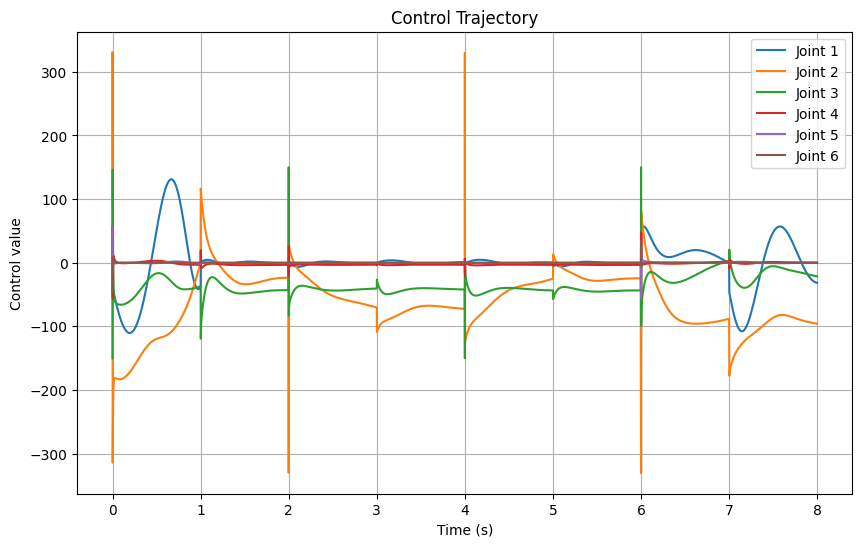

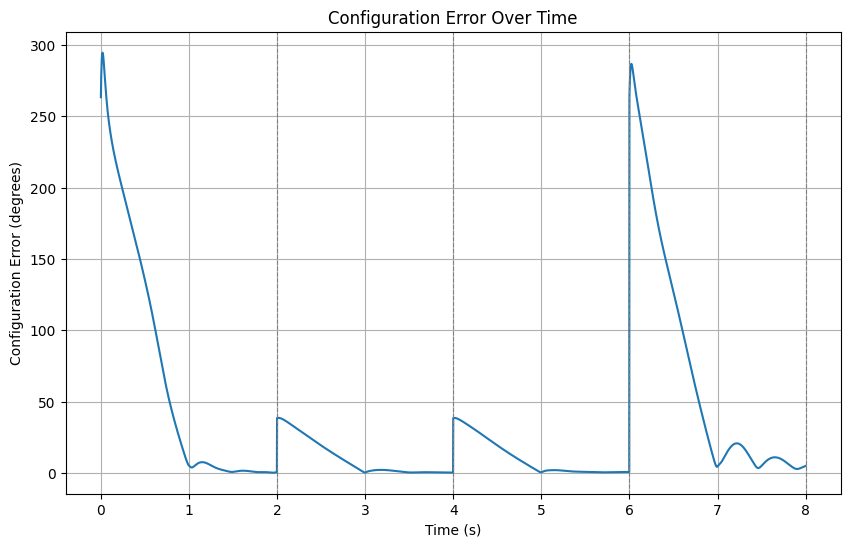

In [8]:
# Visualize Path computed by Mujoco - Open loop control with ideal model
robot_mj_model.visualize("position", xs=xs, dt=DT, hold=False)
robot_mj_model.reset()
# Visualize Path executed by Mujoco - Open loop control without feedback
xs_real, us_real = robot_mj_model.visualize("control", us=us, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)
robot_mj_model.reset()
# Visualize Path executed by Mujoco - Closed loop control with feedback
xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)
robot_mj_model.plot_controls(us_real, dt=DT)
robot_mj_model.plot_error(xs_real, path[1:], segment_lengths=[1000]*len(path), dt=DT)